# BANK LOAN ANALYSIS REPORT

#### importing libraries

In [1]:
import pandas as pd
import sqlalchemy as sa
import urllib
import matplotlib.pyplot as plt
import seaborn as sns




### connecting to mssql database

In [2]:

# Define your connection parameters
params = urllib.parse.quote_plus(
    "Driver={ODBC Driver 18 for SQL Server};"
    "Server=localhost;"  # Or your specific IP address
    "Database=bank_loan;"
    "UID=sa;"            # Default user for Docker MSSQL
    "PWD=Password92;"
    "Encrypt=yes;"
    "TrustServerCertificate=yes;"
)

# Create the engine
engine = sa.create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

print(engine)

df = pd.read_sql("SELECT * FROM bank_loan_data", engine)
df.head()

Engine(mssql+pyodbc:///?odbc_connect=Driver%3D%7BODBC+Driver+18+for+SQL+Server%7D%3BServer%3Dlocalhost%3BDatabase%3Dbank_loan%3BUID%3Dsa%3BPWD%3DPassword92%3BEncrypt%3Dyes%3BTrustServerCertificate%3Dyes%3B)


,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,54734,CA,INDIVIDUAL,< 1 year,NaN,B,RENT,2021-08-09,2021-08-12,2021-10-11,...,B4,36 months,Verified,85000.0,0.1948,829.099976,0.1189,25000,42,29330
1,55742,NY,INDIVIDUAL,< 1 year,CNN,B,RENT,2021-05-08,2021-08-12,2021-06-11,...,B5,36 months,Not Verified,65000.0,0.1429,228.220001,0.1071,7000,7,8216
2,57245,TX,INDIVIDUAL,10+ years,city of beaumont texas,C,OWN,2021-03-10,2021-05-16,2021-03-13,...,C2,36 months,Not Verified,54000.0,0.0547,40.500000,0.1311,1200,31,1458
3,57416,CT,INDIVIDUAL,6 years,State Farm Insurance,C,RENT,2021-11-09,2021-05-16,2021-11-12,...,C3,36 months,Not Verified,32000.0,0.1163,366.859985,0.1357,10800,40,13208
4,58915,CA,INDIVIDUAL,3 years,QUalcomm Inc,B,RENT,2021-04-08,2021-03-14,2021-04-11,...,B3,36 months,Not Verified,85000.0,0.0810,162.339996,0.1008,7500,11,5844


In [3]:
df.shape

(38576, 24)

In [4]:
print("Number of rows:", df.shape[0])

Number of rows: 38576


In [5]:
print("Number of columns:", df.shape[1])

Number of columns: 24


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     38576 non-null  int64  
 1   address_state          38576 non-null  str    
 2   application_type       38576 non-null  str    
 3   emp_length             38576 non-null  str    
 4   emp_title              37143 non-null  str    
 5   grade                  38576 non-null  str    
 6   home_ownership         38576 non-null  str    
 7   issue_date             38576 non-null  object 
 8   last_credit_pull_date  38576 non-null  object 
 9   last_payment_date      38576 non-null  object 
 10  loan_status            38576 non-null  str    
 11  next_payment_date      38576 non-null  object 
 12  member_id              38576 non-null  int64  
 13  purpose                38576 non-null  str    
 14  sub_grade              38576 non-null  str    
 15  term         

In [7]:
df.dtypes

id                         int64
address_state                str
application_type             str
emp_length                   str
emp_title                    str
grade                        str
home_ownership               str
issue_date                object
last_credit_pull_date     object
last_payment_date         object
loan_status                  str
next_payment_date         object
member_id                  int64
purpose                      str
sub_grade                    str
term                         str
verification_status          str
annual_income            float64
dti                      float64
installment              float64
int_rate                 float64
loan_amount                int64
total_acc                  int64
total_payment              int64
dtype: object

In [8]:
df.describe()

,id,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
std,2.113246e+05,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777
min,5.473400e+04,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,6.629788e+05,4.150000e+04,0.082100,168.449997,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,8.473565e+05,6.000000e+04,0.134200,283.044998,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,1.045652e+06,8.320050e+04,0.185900,434.442497,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,1.314167e+06,6.000000e+06,0.299900,1305.189941,0.245900,35000.000000,90.000000,58564.000000


In [9]:
df.isnull().sum()

id                          0
address_state               0
application_type            0
emp_length                  0
emp_title                1433
grade                       0
home_ownership              0
issue_date                  0
last_credit_pull_date       0
last_payment_date           0
loan_status                 0
next_payment_date           0
member_id                   0
purpose                     0
sub_grade                   0
term                        0
verification_status         0
annual_income               0
dti                         0
installment                 0
int_rate                    0
loan_amount                 0
total_acc                   0
total_payment               0
dtype: int64

In [10]:
df.columns

Index(['id', 'address_state', 'application_type', 'emp_length', 'emp_title',
       'grade', 'home_ownership', 'issue_date', 'last_credit_pull_date',
       'last_payment_date', 'loan_status', 'next_payment_date', 'member_id',
       'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income',
       'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc',
       'total_payment'],
      dtype='str')

### Total Loan Amount

In [11]:
total_loan_applicantions = df['id'].count()

print("Total Loan Applications: ", total_loan_applicantions)

Total Loan Applications:  38576


### MTD loan amount

In [12]:
df['issue_date'] = pd.to_datetime(df['issue_date'])
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[ (df['issue_date'].dt.year ==  latest_year) &  (df['issue_date'].dt.month == latest_month) ]
mtd_loan_applications = mtd_data['id'].count()

print( f"MTD loan applications for {latest_issue_date.strftime('%B %Y')} is: {mtd_loan_applications}" )

MTD loan applications for December 2021 is: 4314


### Total Funded Amount

In [13]:
Total_funded_amount = df['loan_amount'].sum()
Total_funded_amount_in_millions = Total_funded_amount / 1000000
print("Total Funded amount is $ {:.2f} M".format(Total_funded_amount_in_millions))

Total Funded amount is $ 435.76 M


### MTD Funded Loan Amount

In [14]:
df['issue_date'] = pd.to_datetime(df['issue_date'])
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[ (df['issue_date'].dt.year ==  latest_year) &  (df['issue_date'].dt.month == latest_month) ]
mtd_funded_loan_amount = mtd_data['loan_amount'].sum()
mtd_funded_loan_amount_in_millions = mtd_funded_loan_amount / 1000000


print(f"MTD Funded Loan Amount for {latest_issue_date.strftime('%B %Y')} is: ${mtd_funded_loan_amount_in_millions:.2f} M")



MTD Funded Loan Amount for December 2021 is: $53.98 M


### Total Loan Amount Received

In [15]:
Total_received_amount = df['total_payment'].sum()
Total_received_amount_in_millions = Total_received_amount / 1000000
print("Total Funded amount is $ {:.2f} M".format(Total_received_amount_in_millions))

Total Funded amount is $ 473.07 M


### MTD  Loan Amount Received

In [16]:
df['issue_date'] = pd.to_datetime(df['issue_date'])
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[ (df['issue_date'].dt.year ==  latest_year) &  (df['issue_date'].dt.month == latest_month) ]
mtd_loan_amount_received = mtd_data['total_payment'].sum()
mtd_loan_amount_received_in_millions = mtd_loan_amount_received / 1000000


print(f"MTD Loan Amount Received for {latest_issue_date.strftime('%B %Y')} is: ${mtd_loan_amount_received_in_millions:.2f} M")

MTD Loan Amount Received for December 2021 is: $58.07 M


### Avg Intrest rate

In [17]:
avg_interest_rate = df['int_rate'].mean()*100
print("Avg Interest Rate is $ {:.2f} %".format(avg_interest_rate))

Avg Interest Rate is $ 12.05 %


### Avg Deat TO Income Ratio i.e DTI

In [18]:
avg_dti = df['dti'].mean()*100
print("Avg Interest Rate is $ {:.2f} %".format(avg_dti))

Avg Interest Rate is $ 13.33 %


### Good Loan Matrix

In [19]:
good_loan_data = df[df['loan_status'].isin(['Fully Paid','Current'])]

total_loan_applicantions = df['id'].count()
good_loan_applications = good_loan_data['id'].count()
good_loan_funded_amount = good_loan_data['loan_amount'].sum() 
good_loan_received_amount = good_loan_data['total_payment'].sum() 

percentage_of_good_loan = (good_loan_applications / total_loan_applicantions) *100

good_loan_funded_amount_in_milions = good_loan_funded_amount / 1000000
good_loan_received_amount_in_milions = good_loan_received_amount /1000000

print("Total Good Loan Applications {:.2f}".format(good_loan_applications))
print("Total Good Loan Applications percentage {:.2f} %".format(percentage_of_good_loan))
print("Total Good Loan Funded amount {:.2f} M".format(good_loan_funded_amount_in_milions))
print("Total Good Loan amount received {:.2f} M".format(good_loan_received_amount_in_milions))

Total Good Loan Applications 33243.00
Total Good Loan Applications percentage 86.18 %
Total Good Loan Funded amount 370.22 M
Total Good Loan amount received 435.79 M


### Bad Loan Matrix


In [20]:
bad_loan_data = df[df['loan_status'].isin(['Charged Off'])]

total_loan_applicantions = df['id'].count()
bad_loan_applications = bad_loan_data['id'].count()
bad_loan_funded_amount = bad_loan_data['loan_amount'].sum() 
bad_loan_received_amount = bad_loan_data['total_payment'].sum() 

percentage_of_bad_loan = (bad_loan_applications / total_loan_applicantions) *100

bad_loan_funded_amount_in_milions = bad_loan_funded_amount / 1000000
bad_loan_received_amount_in_milions = bad_loan_received_amount /1000000

print("Total bad Loan Applications {:.2f}".format(bad_loan_applications))
print("Total bad Loan Applications percentage {:.2f} %".format(percentage_of_bad_loan))
print("Total bad Loan Funded amount {:.2f} M".format(bad_loan_funded_amount_in_milions))
print("Total bad Loan amount received {:.2f} M".format(bad_loan_received_amount_in_milions))

Total bad Loan Applications 5333.00
Total bad Loan Applications percentage 13.82 %
Total bad Loan Funded amount 65.53 M
Total bad Loan amount received 37.28 M


### Monthly trends by issue date for total funded amount

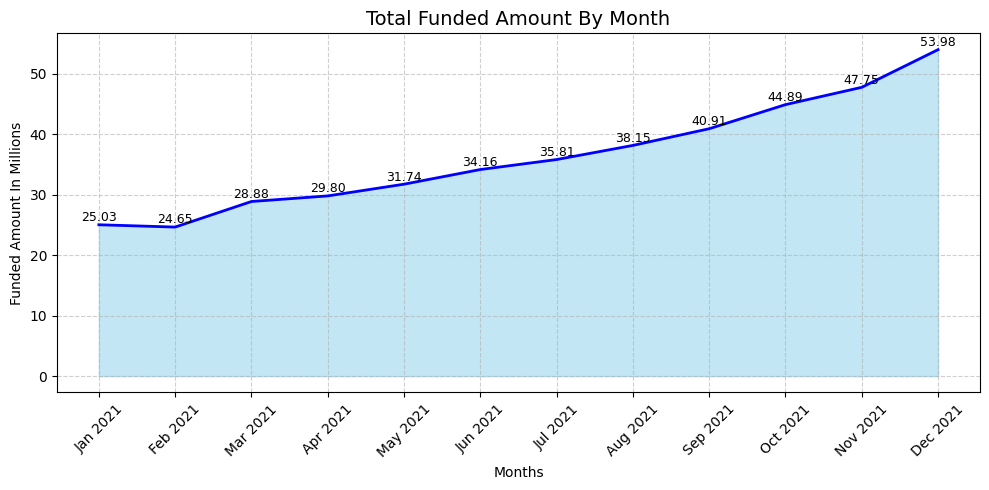

In [21]:
monthly_trends_for_funded_amount =(
	df.sort_values('issue_date')
	.assign(month_name = lambda x: x['issue_date'].dt.strftime('%b %Y'))
	.groupby('month_name', sort = False)['loan_amount']
	.sum()
	.div(1000000)
	.reset_index(name = 'loan_amout_in_millions')
)

plt.figure(figsize = (10, 5))
plt.fill_between(monthly_trends_for_funded_amount['month_name'], monthly_trends_for_funded_amount['loan_amout_in_millions'], color ='skyblue', alpha = 0.5)
plt.plot(monthly_trends_for_funded_amount['month_name'], monthly_trends_for_funded_amount['loan_amout_in_millions'], color ='blue', linewidth = 2)

for i, row in monthly_trends_for_funded_amount.iterrows():
    plt.text(i, row['loan_amout_in_millions'] + 0.1, f"{row['loan_amout_in_millions']:.2f}",
    ha='center', va= 'bottom', fontsize=9, rotation=0, color= 'black')

plt.title("Total Funded Amount By Month", fontsize =14)
plt.xlabel("Months")
plt.ylabel("Funded Amount In Millions")
plt.xticks(ticks = range(len(monthly_trends_for_funded_amount)), labels = monthly_trends_for_funded_amount['month_name'], rotation =45)
plt.grid(True, linestyle = '--', alpha = 0.6)
plt.tight_layout()
plt.show()


### Monthly trends by issue date for total amount received

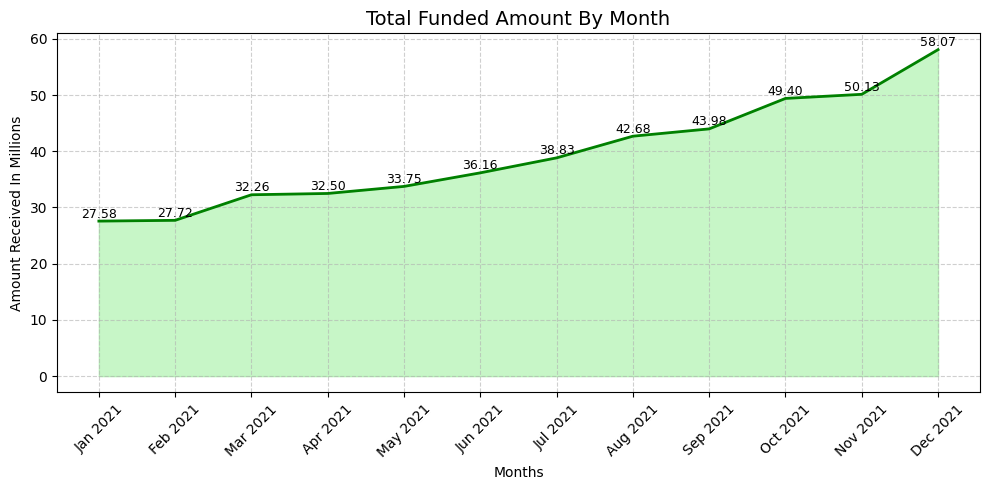

In [22]:
monthly_trends_for_amount_received =(
	df.sort_values('issue_date')
	.assign(month_name = lambda x: x['issue_date'].dt.strftime('%b %Y'))
	.groupby('month_name', sort = False)['total_payment']
	.sum()
	.div(1000000)
	.reset_index(name = 'loan_amout_in_millions')
)

plt.figure(figsize = (10, 5))
plt.fill_between(monthly_trends_for_amount_received['month_name'], monthly_trends_for_amount_received['loan_amout_in_millions'], color ='lightgreen', alpha = 0.5)
plt.plot(monthly_trends_for_amount_received['month_name'], monthly_trends_for_amount_received['loan_amout_in_millions'], color ='green', linewidth = 2)

for i, row in monthly_trends_for_amount_received.iterrows():
    plt.text(i, row['loan_amout_in_millions'] + 0.1, f"{row['loan_amout_in_millions']:.2f}",
    ha='center', va= 'bottom', fontsize=9, rotation=0, color= 'black')

plt.title("Total Funded Amount By Month", fontsize =14)
plt.xlabel("Months")
plt.ylabel("Amount Received In Millions")
plt.xticks(ticks = range(len(monthly_trends_for_amount_received)), labels = monthly_trends_for_amount_received['month_name'], rotation =45)
plt.grid(True, linestyle = '--', alpha = 0.6)
plt.tight_layout()
plt.show()


### Monthly trends by issue date for total loan applicantions

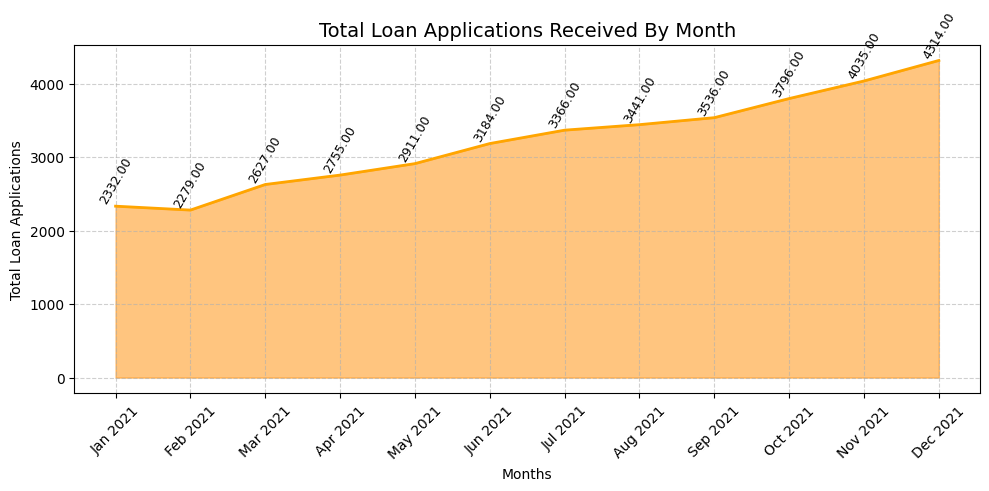

In [23]:
monthly_trends_for_loan_applications_received =(
	df.sort_values('issue_date')
	.assign(month_name = lambda x: x['issue_date'].dt.strftime('%b %Y'))
	.groupby('month_name', sort = False)['id']
	.count()
	.reset_index(name = 'loan_applications_received')
)

plt.figure(figsize = (10, 5))
plt.fill_between(monthly_trends_for_loan_applications_received['month_name'], monthly_trends_for_loan_applications_received['loan_applications_received'], color ='darkorange', alpha = 0.5)
plt.plot(monthly_trends_for_loan_applications_received['month_name'], monthly_trends_for_loan_applications_received['loan_applications_received'], color ='orange', linewidth = 2)

for i, row in monthly_trends_for_loan_applications_received.iterrows():
    plt.text(i, row['loan_applications_received'] + 0.1, f"{row['loan_applications_received']:.2f}",
    ha='center', va= 'bottom', fontsize=9, rotation=60, color= 'black')

plt.title("Total Loan Applications Received By Month", fontsize =14)
plt.xlabel("Months")
plt.ylabel("Total Loan Applications")
plt.xticks(ticks = range(len(monthly_trends_for_loan_applications_received)), labels = monthly_trends_for_loan_applications_received['month_name'], rotation =45)
plt.grid(True, linestyle = '--', alpha = 0.6)
plt.tight_layout()
plt.show()


### Regional analysis by state for total funded amount

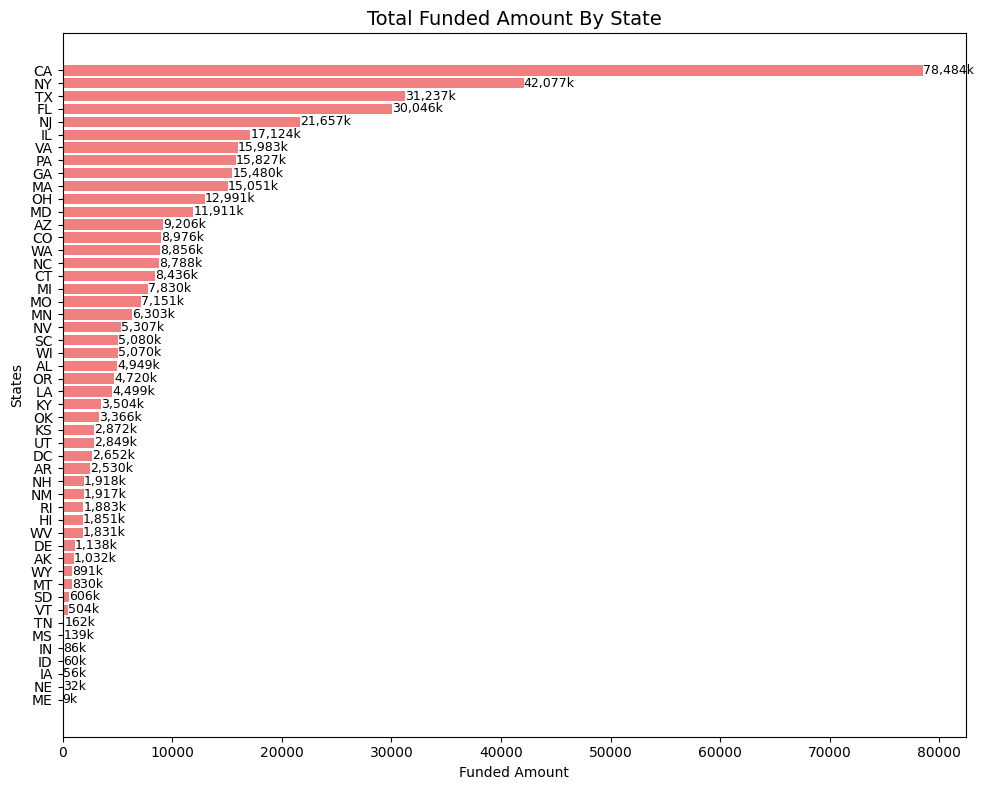

In [24]:
state_funded_amount = df.groupby('address_state')['loan_amount'].sum().sort_values(ascending = True)
state_funded_amount_in_thousands = state_funded_amount / 1000

plt.figure(figsize = (10,8))
bars = plt.barh(state_funded_amount_in_thousands.index, state_funded_amount_in_thousands.values, color = 'lightcoral')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2, f'{width:,.0f}k', va = 'center', fontsize = 9)

plt.title("Total Funded Amount By State", fontsize =14)
plt.xlabel("Funded Amount")
plt.ylabel("States")
plt.tight_layout()
plt.show()

### Regional analysis by state for amount received

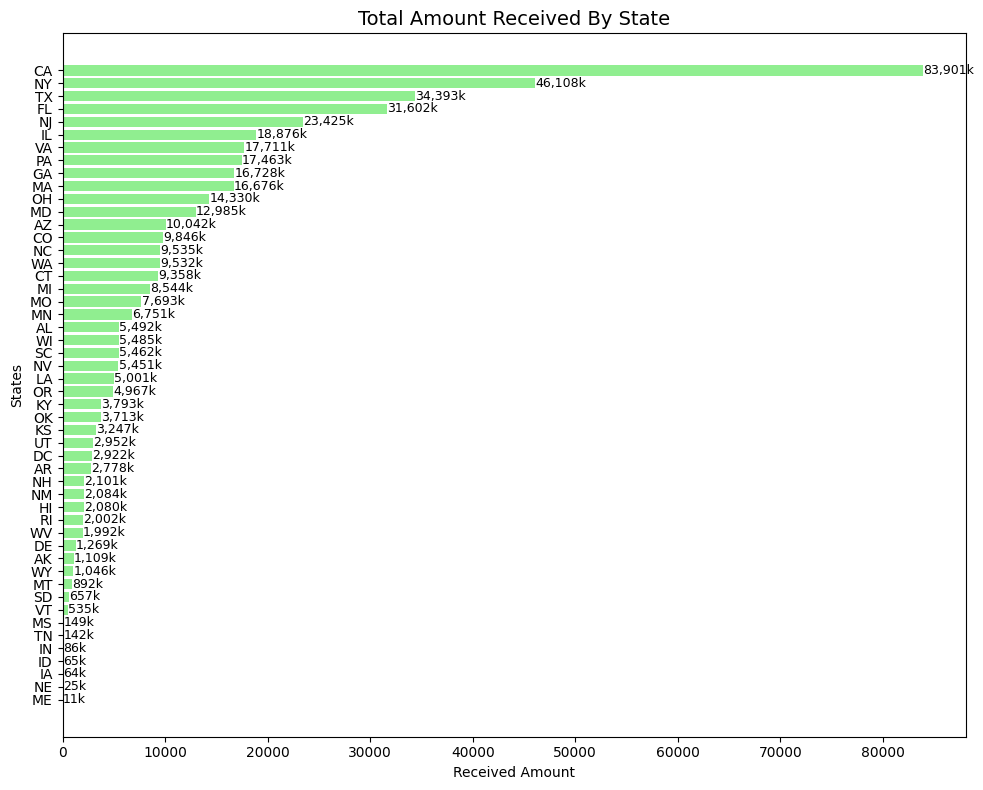

In [25]:
state_amount_received = df.groupby('address_state')['total_payment'].sum().sort_values(ascending = True)
state_amount_received_in_thousands = state_amount_received / 1000

plt.figure(figsize = (10,8))
bars = plt.barh(state_amount_received_in_thousands.index, state_amount_received_in_thousands.values, color = 'lightgreen')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2, f'{width:,.0f}k', va = 'center', fontsize = 9)

plt.title("Total Amount Received By State", fontsize =14)
plt.xlabel("Received Amount")
plt.ylabel("States")
plt.tight_layout()
plt.show()

### Regional analysis by state for loan applications

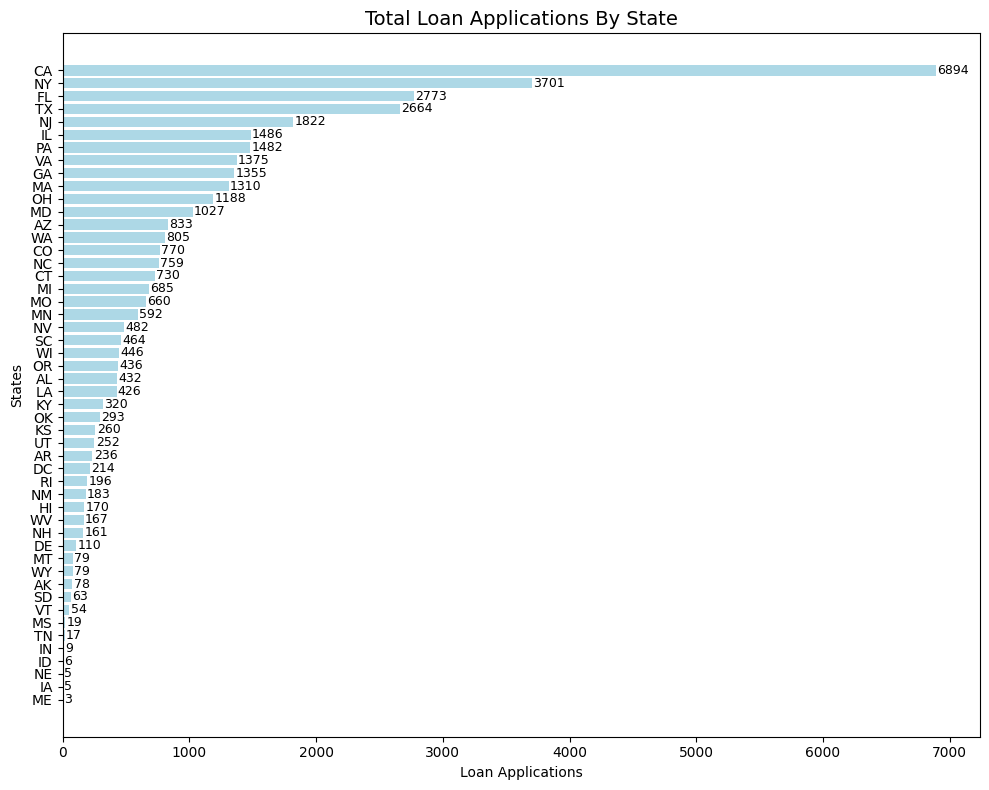

In [78]:
state_loan_applicantions = df.groupby('address_state')['id'].count().sort_values(ascending = True)

plt.figure(figsize = (10,8))
bars = plt.barh(state_loan_applicantions.index, state_loan_applicantions.values, color = 'lightblue')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2, f'{width}', va = 'center', fontsize = 9)

plt.title("Total Loan Applications By State", fontsize =14)
plt.xlabel("Loan Applications")
plt.ylabel("States")
plt.tight_layout()
plt.show()

### Total Funded Amount By Term

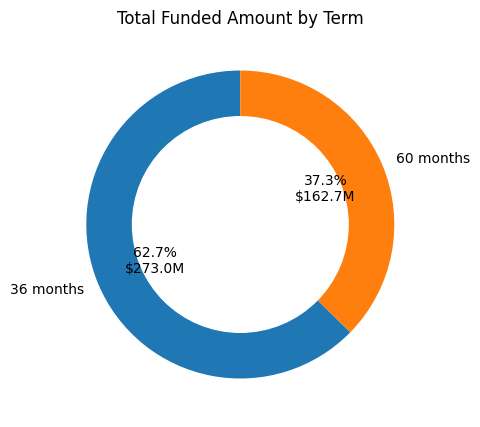

In [36]:
term_funding_millions = df.groupby('term')['loan_amount'].sum() / 1000000

plt.figure(figsize = (5,5))
plt.pie(
	term_funding_millions,
labels = term_funding_millions.index,
autopct = lambda p: f"{p:.1f}%\n${p*sum(term_funding_millions)/100:.1f}M", 
startangle = 90,
wedgeprops = {'width': 0.4}
)

plt.gca().add_artist(plt.Circle((0,0), 0.70, color = 'white'))
plt.title("Total Funded Amount by Term")
plt.show()

### Total loan amount received by term

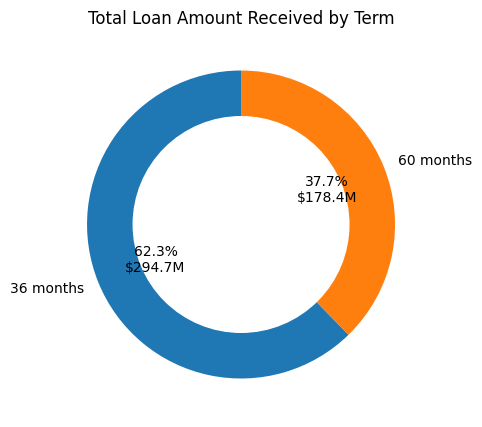

In [50]:
term_received_millions = df.groupby('term')['total_payment'].sum() / 1000000

plt.figure(figsize = (5,5))
plt.pie(
	term_received_millions,
labels = term_received_millions.index,
autopct = lambda p: f"{p:.1f}%\n${p*sum(term_received_millions)/100:.1f}M", 
startangle = 90,
wedgeprops = {'width': 0.4}
)

plt.gca().add_artist(plt.Circle((0,0), 0.70, color = 'white'))
plt.title("Total Loan Amount Received by Term")
plt.show()

### Total loan applications by term

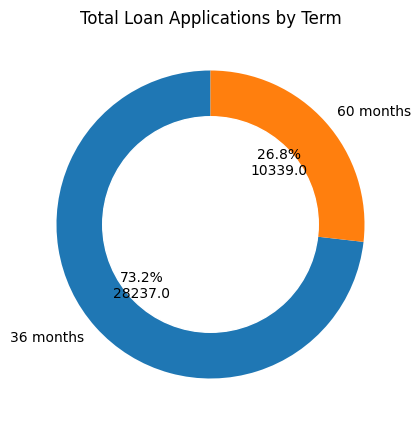

In [65]:
term_applications = df.groupby('term')['id'].count()

plt.figure(figsize = (5,5))
plt.pie(
	term_applications,
labels = term_applications.index,
autopct = lambda p: f"{p:.1f}%\n{p*sum(term_applications) / 100:.1f}", 
startangle = 90,
wedgeprops = {'width': 0.4}
)

plt.gca().add_artist(plt.Circle((0,0), 0.70, color = 'white'))
plt.title("Total Loan Applications by Term")
plt.show()

### Employee Length By Total Funded Amount

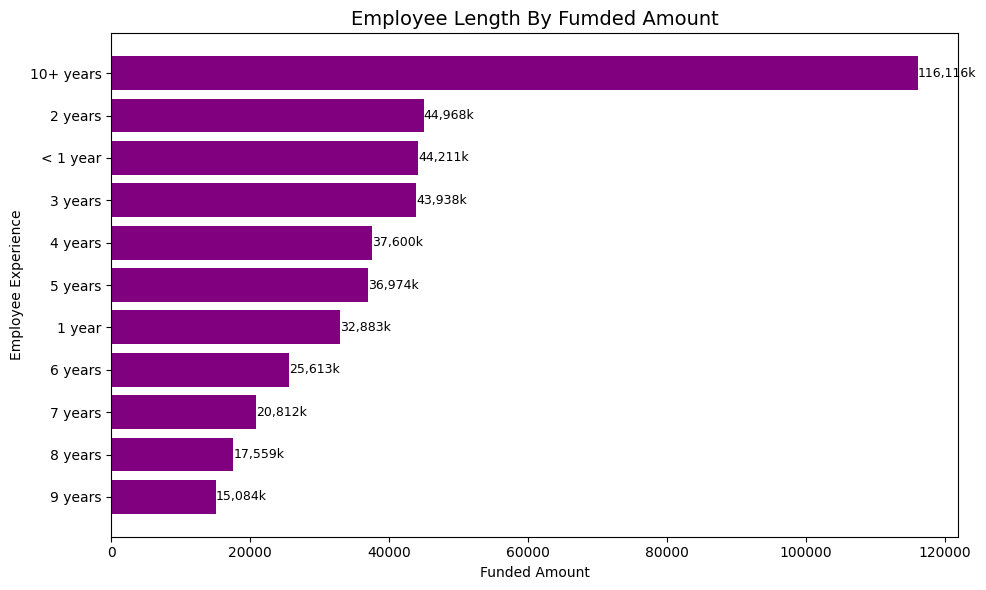

In [93]:
emp_funded_amount = df.groupby('emp_length')['loan_amount'].sum().sort_values(ascending = True) 
emp_funded_amount_in_thousands = emp_funded_amount / 1000

plt.figure(figsize = (10,6))
bars = plt.barh(emp_funded_amount_in_thousands.index, emp_funded_amount_in_thousands.values, color = 'purple')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2, f'{width:,.0f}k', va = 'center', fontsize = 9)

plt.title("Employee Length By Fumded Amount", fontsize =14)
plt.xlabel("Funded Amount")
plt.ylabel("Employee Experience")
plt.tight_layout()
plt.show()

### Employee Lengh by Loan Amount Received

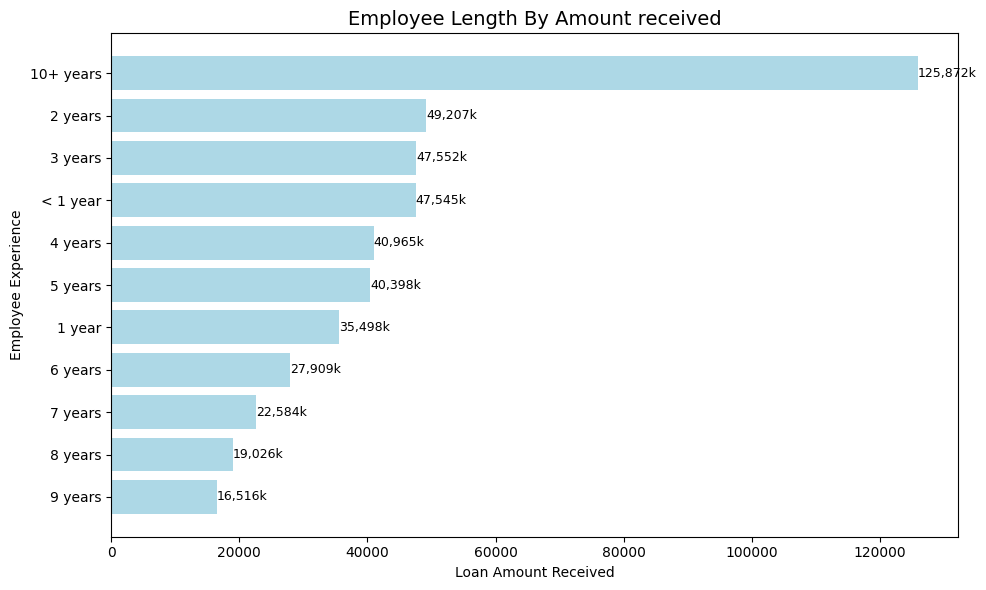

In [86]:
emp_amount_received = df.groupby('emp_length')['total_payment'].sum().sort_values(ascending = True) 
emp_amount_received_in_thousands = emp_amount_received / 1000

plt.figure(figsize = (10,6))
bars = plt.barh(emp_amount_received_in_thousands.index, emp_amount_received_in_thousands.values, color = 'lightblue')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2, f'{width:,.0f}k', va = 'center', fontsize = 9)

plt.title("Employee Length By Amount received", fontsize =14)
plt.xlabel("Loan Amount Received")
plt.ylabel("Employee Experience")
plt.tight_layout()
plt.show()

### Employee length by Total applications

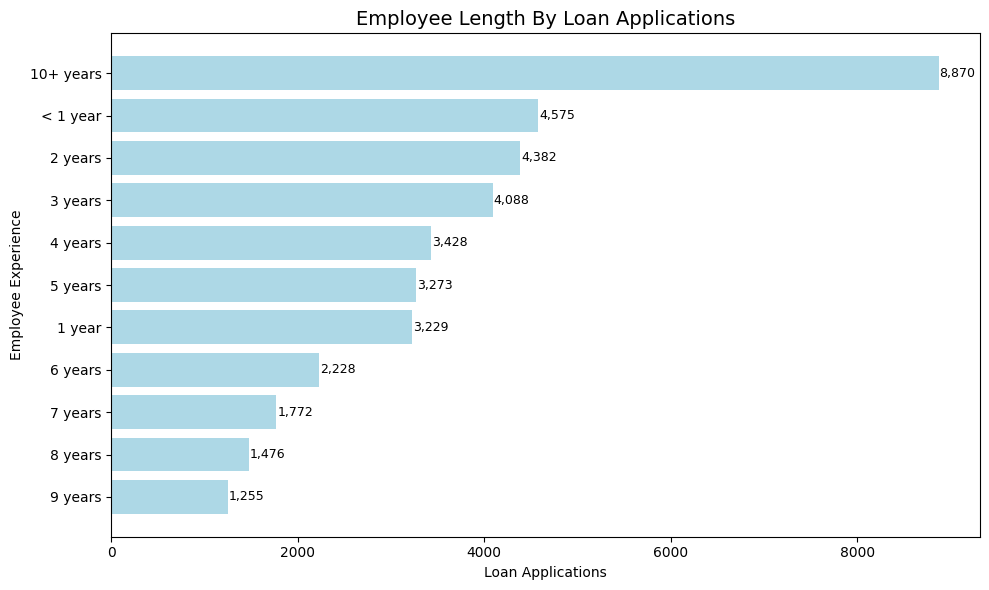

In [89]:
emp_applications = df.groupby('emp_length')['id'].count().sort_values(ascending = True) 

plt.figure(figsize = (10,6))
bars = plt.barh(emp_applications.index, emp_applications.values, color = 'lightblue')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2, f'{width:,.0f}', va = 'center', fontsize = 9)

plt.title("Employee Length By Loan Applications", fontsize =14)
plt.xlabel("Loan Applications")
plt.ylabel("Employee Experience")
plt.tight_layout()
plt.show()

### Loan purppose by funded amount

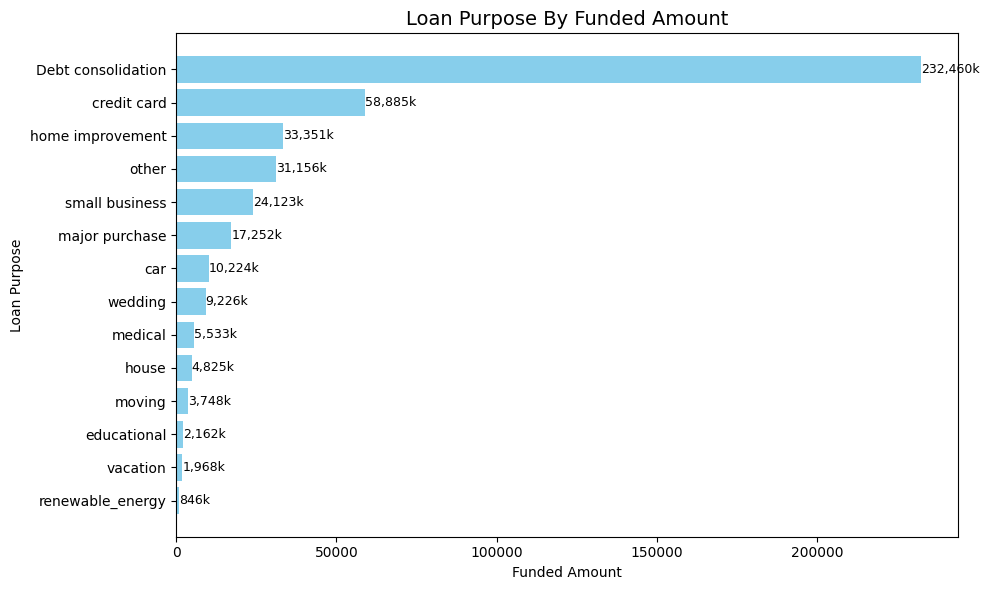

In [94]:
purpose_funded_amount = df.groupby('purpose')['loan_amount'].sum().sort_values(ascending = True) 
purpose_funded_amount_in_thousands = purpose_funded_amount / 1000

plt.figure(figsize = (10,6))
bars = plt.barh(purpose_funded_amount_in_thousands.index, purpose_funded_amount_in_thousands.values, color = 'skyblue')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height() / 2, f'{width:,.0f}k', va = 'center', fontsize = 9)

plt.title("Loan Purpose By Funded Amount", fontsize =14)
plt.xlabel("Funded Amount")
plt.ylabel("Loan Purpose")
plt.tight_layout()
plt.show()